In [1]:
from datasets import load_dataset
dataset = load_dataset("swami93/indian-names-1.5M")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md:   0%|          | 0.00/528 [00:00<?, ?B/s]

names_dataset.txt: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/114239 [00:00<?, ? examples/s]

In [2]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 114239
    })
})

In [3]:
names = dataset["train"]["text"]
names

Column(['name: thiv', 'name: ziyan', 'name: del', 'name: bharathushan', 'name: aranamuthan'])

In [4]:
cleaned_names = []
for line in names:
    cleaned_names.append(line.strip().replace("name: ",""))
print(cleaned_names[:10])


['thiv', 'ziyan', 'del', 'bharathushan', 'aranamuthan', 'saptahotre', 'lakshay', 'mangaraj', 'gopitha', 'jeylani']


In [ ]:
len(cleaned_names)

114239

In [ ]:
min(len(name) for name in cleaned_names)

1

In [7]:
max(len(name) for name in cleaned_names)

15

In [8]:
chars = sorted(list(set("".join(cleaned_names))))

In [ ]:
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi["."] = 0
itos = {i:s for s,i in stoi.items()}

In [ ]:
#stoi

{'a': 1,
 'b': 2,
 'c': 3,
 'd': 4,
 'e': 5,
 'f': 6,
 'g': 7,
 'h': 8,
 'i': 9,
 'j': 10,
 'k': 11,
 'l': 12,
 'm': 13,
 'n': 14,
 'o': 15,
 'p': 16,
 'q': 17,
 'r': 18,
 's': 19,
 't': 20,
 'u': 21,
 'v': 22,
 'w': 23,
 'x': 24,
 'y': 25,
 'z': 26,
 '.': 0}

In [ ]:
#itos

{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 0: '.'}

In [12]:
import torch

In [35]:
#dataset creation
block_size = 3 # context length
X , Y = [] , []
for name in cleaned_names:
    #print(name)
    context = [0] * block_size
    for ch in name + ".":
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        #print("".join(itos[i] for i in context),"-->", ch)
        context = context[1:] + [ix] # crop and append
        
X = torch.tensor(X)
Y = torch.tensor(Y)
        

In [36]:
X.shape , X.dtype, Y.shape, Y.dtype

(torch.Size([1016894, 3]), torch.int64, torch.Size([1016894]), torch.int64)

In [ ]:
context

[1, 14, 0]

In [ ]:
#X

tensor([[ 0,  0,  0],
        [ 0,  0, 20],
        [ 0, 20,  8],
        [20,  8,  9],
        [ 8,  9, 22],
        [ 0,  0,  0],
        [ 0,  0, 26],
        [ 0, 26,  9],
        [26,  9, 25],
        [ 9, 25,  1],
        [25,  1, 14],
        [ 0,  0,  0],
        [ 0,  0,  4],
        [ 0,  4,  5],
        [ 4,  5, 12],
        [ 0,  0,  0],
        [ 0,  0,  2],
        [ 0,  2,  8],
        [ 2,  8,  1],
        [ 8,  1, 18],
        [ 1, 18,  1],
        [18,  1, 20],
        [ 1, 20,  8],
        [20,  8, 21],
        [ 8, 21, 19],
        [21, 19,  8],
        [19,  8,  1],
        [ 8,  1, 14],
        [ 0,  0,  0],
        [ 0,  0,  1],
        [ 0,  1, 18],
        [ 1, 18,  1],
        [18,  1, 14],
        [ 1, 14,  1],
        [14,  1, 13],
        [ 1, 13, 21],
        [13, 21, 20],
        [21, 20,  8],
        [20,  8,  1],
        [ 8,  1, 14]])

In [ ]:
#Y

tensor([20,  8,  9, 22,  0, 26,  9, 25,  1, 14,  0,  4,  5, 12,  0,  2,  8,  1,
        18,  1, 20,  8, 21, 19,  8,  1, 14,  0,  1, 18,  1, 14,  1, 13, 21, 20,
         8,  1, 14,  0])

In [18]:
C = torch.randn((27,2))
emb = C[X]
emb.shape

torch.Size([40, 3, 2])

In [19]:
#weights and bias
W1 = torch.randn((6,100))
b1 = torch.randn(100)

In [20]:
W1

tensor([[ 9.8632e-02, -4.5817e-01, -7.8159e-01, -7.7448e-01, -8.5523e-01,
          1.4929e+00, -2.0110e-01,  2.0452e+00,  2.1815e-01,  3.6823e-02,
          1.6765e+00, -2.7538e-03, -1.2385e+00, -1.3428e+00,  1.0490e+00,
          1.2084e+00,  5.9513e-01, -1.1597e+00, -4.5505e-01, -7.2022e-01,
          8.6267e-02, -1.6008e+00, -1.2367e+00, -7.6381e-02,  7.1286e-01,
          5.3252e-01,  1.0496e+00,  1.3123e-01, -7.2245e-02,  6.7243e-01,
          6.6726e-01, -2.5759e-02, -1.4466e+00,  1.3126e+00, -3.8093e-01,
         -2.6968e-01,  6.9459e-02,  1.1407e+00, -9.8359e-01,  4.3514e-01,
          8.1587e-01, -1.0486e+00, -1.0902e+00, -1.3403e+00, -2.6067e-01,
         -1.7460e-01, -3.7556e-01, -9.8370e-01, -1.5883e+00,  1.4039e+00,
          3.5709e-01,  4.9497e-01, -3.3178e+00, -2.2076e-01,  6.4655e-01,
          3.2063e-01, -4.5415e-01, -7.9333e-01, -7.5322e-02,  1.1085e+00,
         -1.2933e+00, -1.4167e-01,  1.4492e-01,  7.9925e-01,  7.5482e-03,
          9.7811e-01, -2.2716e-01,  1.

In [21]:
#hidden layer
h = torch.tanh(emb.view(-1,6) @ W1 + b1)
h.shape

torch.Size([40, 100])

In [22]:
h

tensor([[ 0.9679, -0.7925,  0.9890,  ...,  0.9999, -0.2392, -0.9998],
        [ 0.7982,  0.0984,  1.0000,  ...,  0.9964, -0.9582, -0.9993],
        [-0.8921,  0.9974,  0.9998,  ..., -0.9947,  0.4314, -0.9999],
        ...,
        [-0.8974,  0.9837,  0.9651,  ..., -0.9999, -0.6265, -1.0000],
        [ 0.0543, -0.0273,  0.8216,  ..., -0.6167, -0.9564, -0.9997],
        [-0.1504,  0.9658, -0.9751,  ..., -0.9909,  0.6627, -0.8707]])

In [23]:
#weights and biases for output layer
W2 = torch.randn((100,27))
b2 = torch.randn(27)

In [24]:
logits = h @ W2 + b2
logits.shape

torch.Size([40, 27])

In [25]:
counts = logits.exp()
probs = counts / counts.sum(1, keepdim=True)
probs.shape

torch.Size([40, 27])

In [31]:
probs[1].sum()

tensor(1.0000)

In [32]:
loss = -probs[torch.arange(len(Y)),Y].log().mean()

In [33]:
import torch.nn.functional as F

In [34]:
F.cross_entropy(logits,Y)

tensor(17.2637)

#### now in a more respectable way

In [1]:
from datasets import load_dataset
import torch
import torch.nn.functional as F

#import dataset
dataset = load_dataset("swami93/indian-names-1.5M")
names = dataset["train"]["text"]
cleaned_names = []
for line in names:
    cleaned_names.append(line.strip().replace("name: ",""))
#creating the vocabulary
chars = sorted(list(set("".join(cleaned_names))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi["."] = 0
itos = {i:s for s,i in stoi.items()}

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md:   0%|          | 0.00/528 [00:00<?, ?B/s]

names_dataset.txt: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/114239 [00:00<?, ? examples/s]

In [22]:
#dataset creation
block_size = 3 # context length
X , Y = [] , []
for name in cleaned_names:
    context = [0] * block_size
    for ch in name + ".":
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        context = context[1:] + [ix] # crop and append
        
X = torch.tensor(X)
Y = torch.tensor(Y)

In [23]:
X.shape , X.dtype, Y.shape, Y.dtype

(torch.Size([1016894, 3]), torch.int64, torch.Size([1016894]), torch.int64)

In [24]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,2), generator=g)
W1 = torch.randn((6,100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100,27), generator=g)
b2 = torch.randn(27, generator=g)
params = [C, W1, b1, W2, b2]

In [25]:
sum(p.nelement() for p in params)

3481

In [26]:
lre = torch.linspace(-3,0,1000)
lrs = 10**lre

In [27]:
for p in params:
    p.requires_grad = True

In [28]:
lri = []
lossi = []

for i in range(1000):
    #construct a minibatch
    ix = torch.randint(0,X.shape[0], (40,))
    #forward pass
    emb = C[X[ix]]
    h = torch.tanh(emb.view(-1,6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits,Y[ix])
    print(loss.item())
    
    #backward pass
    for p in params:
        p.grad = None
    loss.backward()
    
    #update
    lr = lrs[i]
    for p in params:
        p.data += -lr * p.grad
        
    #track stats
    lri.append(lre[i])
    lossi.append(loss.item())

20.88028335571289
21.277698516845703
18.9263858795166
18.63844108581543
19.286474227905273
17.8397159576416
18.942913055419922
18.92859649658203
18.952173233032227
19.854997634887695
17.59389877319336
18.687450408935547
20.9432315826416
22.835119247436523
18.814434051513672
20.222280502319336
18.48978042602539
19.678844451904297
21.76848602294922
19.273807525634766
17.624406814575195
18.30464744567871
19.74945068359375
19.487224578857422
18.88510513305664
20.858898162841797
17.020647048950195
16.42185401916504
20.201631546020508
18.702531814575195
17.719018936157227
17.186662673950195
19.383377075195312
17.27924346923828
16.25565528869629
16.3891658782959
19.21052360534668
18.204992294311523
18.09482192993164
20.629152297973633
19.152111053466797
16.916091918945312
17.18189239501953
18.66533851623535
17.205219268798828
18.549068450927734
20.5247859954834
19.484298706054688
19.8225154876709
19.12026023864746
17.707027435302734
18.09381103515625
18.151268005371094
19.64240837097168
17.75

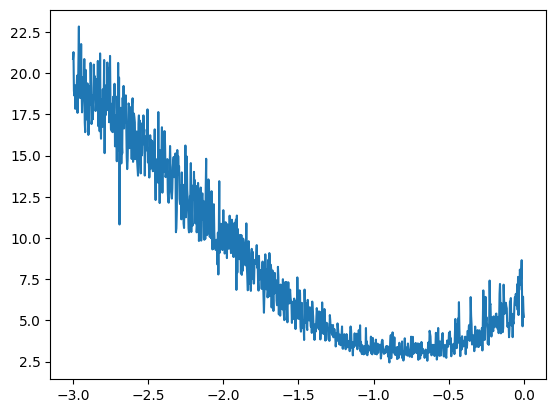

In [29]:
import matplotlib.pyplot as plt
plt.plot(lri, lossi)

In [8]:
torch.randint(0,X.shape[0],(32,))

tensor([784369, 978148,   1505, 951373, 389652, 778451, 618378, 527973, 717454,
        360654, 657933, 684948, 222943, 227605, 180049, 841820, 681051,  56931,
        414720, 942855, 107681, 111046, 433799, 379152, 674052, 335025,  67012,
        679725, 373152, 785280,   7879, 383071])